#### **Importing all the libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import joblib

#### **1.Load DataSet and Data Cleaning**

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

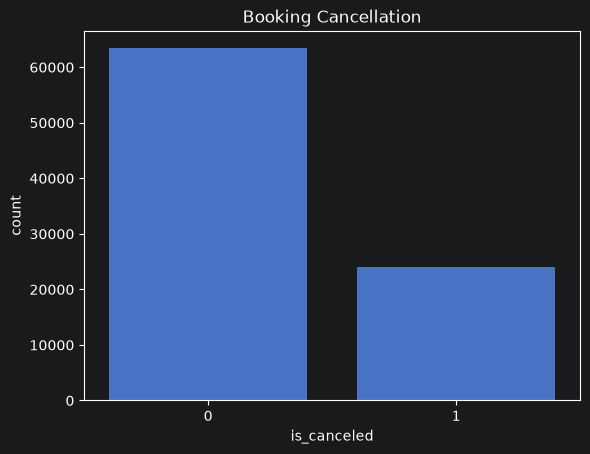

In [9]:
df = pd.read_csv("hotel_bookings.csv")

print(df.head())
print(df.info())

df.drop_duplicates(inplace=True)

df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)

sns.countplot(x="is_canceled", data=df)
plt.title("Booking Cancellation")
plt.show()

#### **2.Data Preprocessing**

In [11]:
encoder = LabelEncoder()

for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#### **3.Model Training and Prediction**

In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#### **4.Printing the accuracy, precision and recall scores of the model**

In [13]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12733
           1       1.00      1.00      1.00      4747

    accuracy                           1.00     17480
   macro avg       1.00      1.00      1.00     17480
weighted avg       1.00      1.00      1.00     17480



#### **5.Error Analysis and Feature Importance**

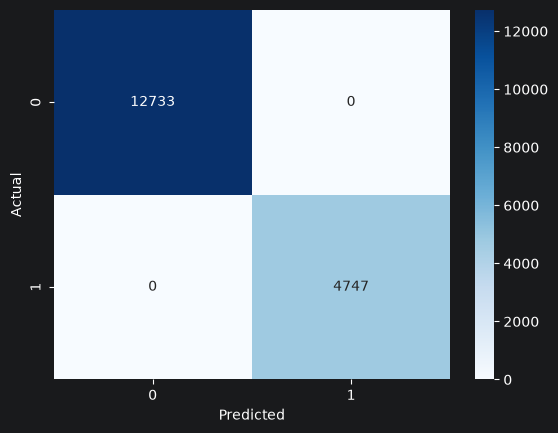

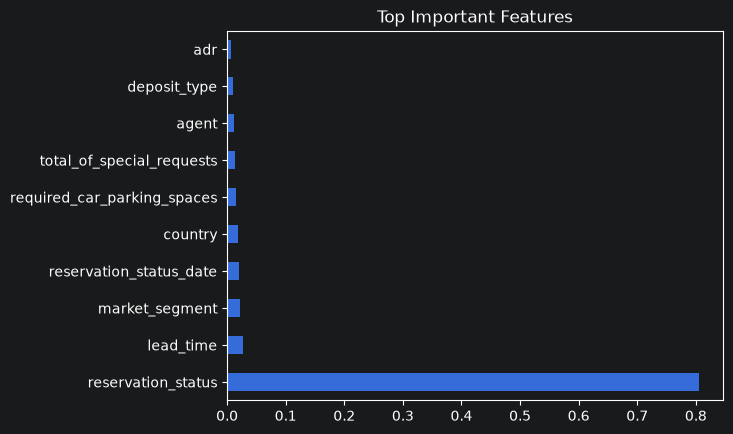

In [14]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.nlargest(10).plot(kind="barh")

plt.title("Top Important Features")

plt.show()


#### **6. Save the model**

In [15]:
joblib.dump(model, "hotel_booking_model.pkl")

['hotel_booking_model.pkl']

#### 7.**Testing the Model**

In [24]:
print("===== Testing on a Sample Booking =====")

index = 55   # Change this to test different bookings

sample = X_test.iloc[[index]]

prediction = model.predict(sample)

actual = y_test.iloc[index]

print(f"Actual Value    : {'CANCELLED' if actual == 1 else 'NOT CANCELLED'}")
print(f"Predicted Value : {'CANCELLED' if prediction[0] == 1 else 'NOT CANCELLED'}")

if actual == prediction[0]:
    print("Result          :  Correct Prediction")
else:
    print("Result          :  Incorrect Prediction")

===== Testing on a Sample Booking =====
Actual Value    : NOT CANCELLED
Predicted Value : NOT CANCELLED
Result          :  Correct Prediction
